In [1]:
import tensorflow as tf

In [2]:
from tensorflow.keras.layers import Dense, Conv1D, concatenate, Flatten, GRU ,Input

In [3]:
def block(input, stride=2):

  conv1 = Conv1D(filters=32, kernel_size=2, activation='relu',  strides=stride, padding='causal')(input) # padding= causal for preventing data leakage (future access of data )
  conv2 = Conv1D(filters=32, kernel_size=4, activation='relu',  strides=stride, padding='causal')(input)
  conv3 = Conv1D(filters=32, kernel_size=8, activation='relu',  strides=stride, padding='causal')(input)
  print(conv2.shape)
  x  = concatenate([conv1,conv2,conv3], axis=2)
  return x

#  Convolutional layers

In [4]:
#input = Input(shape=(15000,22))
input = Input(shape=(640,14))
block1 = block(input)
print(block1.shape)
block2=block(block1, stride= 2)
print(block2.shape)
block3=block(block2)
print(block3.shape)

(None, 320, 32)
(None, 320, 96)
(None, 160, 32)
(None, 160, 96)
(None, 80, 32)
(None, 80, 96)


# GRU layers

In [5]:
gru1 = GRU(units=32,return_sequences=True)(block3)
print(gru1.shape)
gru2 = GRU(units=32,return_sequences=True)(gru1)
print(gru2.shape)
gru_con1 = concatenate([gru1,gru2],axis=2)
print(gru_con1.shape)
gru3= GRU(units=32,return_sequences=True)(gru_con1)
print(gru3.shape)
gru_con2 = concatenate([gru1,gru2,gru3],axis=2)
print(gru_con2.shape)
gru_last=GRU(units=32,return_sequences=False)(gru_con2) #(correction) TRUE OR FALSE ??False as we dont need spatial/time dimension info in ANN or dense neural network
print(gru_last.shape)
output=Dense(1,activation='sigmoid')(gru_last)
print(output.shape)

(None, 80, 32)
(None, 80, 32)
(None, 80, 64)
(None, 80, 32)
(None, 80, 96)
(None, 32)
(None, 1)


# compiling the model

In [6]:
from tensorflow.keras.models import Model
model = Model(inputs=input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 640, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 320, 32)   │        928 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 320, 32)   │      1,824 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 320, 32)   │      3,616 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 320, 96)   │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 160, 32)   │      6,176 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 160, 32)   │     12,320 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 160, 32)   │     24,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 160, 96)   │          0 │ conv1d_3[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 80, 32)    │      6,176 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 80, 32)    │     12,320 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 80, 32)    │     24,608 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 80, 96)    │          0 │ conv1d_6[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_7[0][0],   │
│                     │                   │            │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 80, 32)    │     12,480 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 80, 32)    │      6,336 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 80, 64)    │          0 │ gru[0][0],        │
│ (Concatenate)       │                   │            │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 80, 32)    │      9,408 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 80, 96)    │          0 │ gru[0][0],        │
│ (Concatenate)       │                   │            │ gru_1[0][0],      │
│                     │                   │            │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 32)        │     12,480 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │         33 │ gru_3[0][0]     

 Total params: 133,313 (520.75 KB)

 Trainable params: 133,313 (520.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
print(model.count_params())

133313


# Data prep + Training

In [8]:

def plot_loss_curves(history):

  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(0,20)

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend()


In [9]:
!pip install mne -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 106.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne


In [11]:
import os

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
eeg_path=[]
meta_path=[]
for root, dir , files in os.walk('/content/drive'):

   for file in files:
    if file.endswith(('.csv', '.zip')):

      if 'nig' in file.lower() :
         eeg_path.append (os.path.join(root,file))
      if 'meta' in file.lower():
         meta_path.append ( os.path.join(root,file))





In [14]:
eeg_path

['/content/drive/MyDrive/ML_Datasets/metadata_nigeria.csv',
 '/content/drive/MyDrive/ML_Datasets/EEGs_Nigeria.zip']

In [15]:
meta_path

['/content/drive/MyDrive/ML_Datasets/metadata_nigeria.csv']

In [16]:
eeg_path.pop(0)

'/content/drive/MyDrive/ML_Datasets/metadata_nigeria.csv'

In [17]:
eeg_path

['/content/drive/MyDrive/ML_Datasets/EEGs_Nigeria.zip']

In [18]:
import zipfile
with zipfile.ZipFile(eeg_path[0], 'r') as eeg:
    eeg.extractall('data')

In [19]:
def convertDF2MNE(sub):
    info = mne.create_info(list(sub.columns), ch_types=['eeg'] * len(sub.columns), sfreq=128)
    info.set_montage('standard_1020')
    data=mne.io.RawArray(sub.T, info)
    data.set_eeg_reference()
    data.filter(l_freq=1,h_freq=30)
    epochs=mne.make_fixed_length_epochs(data,duration=5,overlap=1)
    epochs=epochs.drop_bad()
    return epochs.get_data()

In [20]:
meta_df = pd.read_csv(meta_path[0])

In [21]:
EP_sub = meta_df['subject.id'][meta_df['Group']=='epilepsy']
CT_sub = meta_df['subject.id'][meta_df['Group']=='control']
def appender(items,limit):
  iter = 0
  item = []
  for i in items:
    if (iter==limit):
      break
    try:
      reader = pd.read_csv('data/EEGs_Nigeria/signal-{}-1.csv.gz'.format(i), compression='gzip')
      item.append(reader)
      iter=iter+1
    except:
      try:
        reader = pd.read_csv('data/EEGs_Nigeria/signal-{}-2.csv.gz'.format(i), compression='gzip')
        item.append(reader)
        iter=iter+1
      except:
        pass
  return item
Epilepsy = appender(EP_sub,51)
Control = appender(CT_sub,46)
Epilepsy2 = [i.iloc[:,1:15] for i in  Epilepsy]
Control2 = [i.iloc[:,1:15] for i in  Control]
idd_subject =[convertDF2MNE(i) for i in  Epilepsy2]
tdc_subject = [convertDF2MNE(i) for i in  Control2]

Creating RawArray with float64 data, n_channels=14, n_times=34304
    Range : 0 ... 34303 =      0.000 ...   267.992 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 423 samples (3.305 s)

Not setting metadata
66 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 66 events and 640 original time points ...
0 bad epochs drop

In [22]:
control_epochs_labels=[len(i)*[0] for i in tdc_subject]
patients_epochs_labels=[len(i)*[1] for i in idd_subject]

data_list=tdc_subject+idd_subject
label_list=control_epochs_labels+patients_epochs_labels
groups_list=[[i]*len(j) for i, j in enumerate(data_list)]

# labeling data
data_array=np.concatenate(data_list)
label_array=np.concatenate(label_list)
group_array=np.concatenate(groups_list)
data_array=np.moveaxis(data_array,1,2)

print(data_array.shape,label_array.shape,group_array.shape)

(6127, 640, 14) (6127,) (6127,)


In [23]:
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
gkf=GroupKFold()

In [24]:
for train_index, val_index in gkf.split(data_array, label_array, groups=group_array):
    train_features,train_labels=data_array[train_index],label_array[train_index]
    val_features,val_labels=data_array[val_index],label_array[val_index]
    scaler=StandardScaler()
    train_features = scaler.fit_transform(train_features.reshape(-1, train_features.shape[-1])).reshape(train_features.shape)
    val_features = scaler.transform(val_features.reshape(-1, val_features.shape[-1])).reshape(val_features.shape)

In [25]:
chrononet_history = model.fit(train_features,
                              train_labels,
                              epochs=20,
                              validation_data=(val_features, val_labels),
                            )

Epoch 1/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.5803 - loss: 0.6719 - val_accuracy: 0.6462 - val_loss: 0.6290
Epoch 2/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7745 - loss: 0.4873 - val_accuracy: 0.8049 - val_loss: 0.4260
Epoch 3/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8639 - loss: 0.3341 - val_accuracy: 0.7547 - val_loss: 0.5704
Epoch 4/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8837 - loss: 0.2775 - val_accuracy: 0.8267 - val_loss: 0.4011
Epoch 5/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9043 - loss: 0.2351 - val_accuracy: 0.8397 - val_loss: 0.3899
Epoch 6/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9309 - loss: 0.1857 - val_accuracy: 0.6802 - val_loss: 0.7509
Epoch 7/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9444 - loss: 0.1443 - val_accuracy: 0.8113 - val_loss: 0.5604
Epoch 8/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9540 - loss: 0.1233 - val_acc

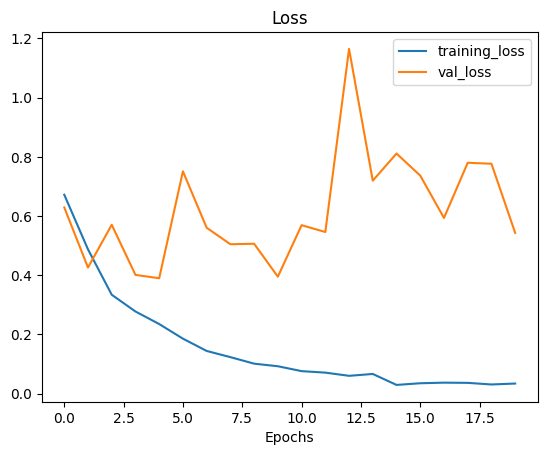

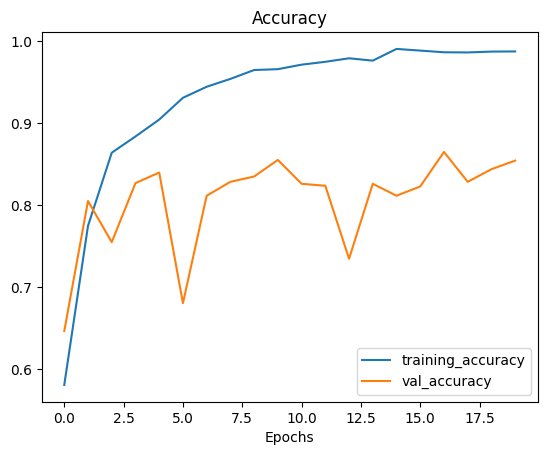

In [26]:
plot_loss_curves(chrononet_history)